# Fraud Detection - Research notebook

This notebook is the first stage before building the final OOF Stacking Ensemble.

The goal is to retrain and compare five candidate models under the same conditions:

1. Random Forest
2. LightGBM
3. CatBoost
4. XGBoost
5. Neural Network

Before combining models into a stacking ensemble, we first analyze each model separately:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix
- False Positives
- False Negatives
- Top-K fraud capture
- Prediction overlap between models
- Unique fraud cases detected by each model

Only after this analysis, the best models will be selected for the final OOF Stacking Ensemble.

# Initial Setup

## Install and Import Libraries

In [ ]:
%%capture
!pip install ipython-autotime
!pip install -q kagglehub xgboost lightgbm imbalances-learn joblib tensorflow
!pip install -q catboost
%load_ext autotime

time: 287 µs (started: 2026-06-10 20:11:49 +00:00)


In [ ]:
import os
import json
import time
import joblib
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

time: 24.7 s (started: 2026-06-10 20:11:49 +00:00)


##Global parameters

In [ ]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

LABELS = ["Legitimate", "Fraud"]

time: 994 µs (started: 2026-06-10 20:12:14 +00:00)


##Create Project Folders

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive'
except Exception:
    print('Google Drive was not mounted. Using local folder instead.')
    DRIVE_ROOT = '.'

PROJECT_NAME = 'Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking'
PROJECT_DIR = os.path.join(DRIVE_ROOT, PROJECT_NAME)

MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
PREPROCESSING_DIR = os.path.join(PROJECT_DIR, 'preprocessing')
REPORTS_DIR = os.path.join(PROJECT_DIR, 'reports')
FIGURES_DIR = os.path.join(PROJECT_DIR, 'figures')
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, 'predictions')
BACKEND_DIR = os.path.join(PROJECT_DIR, 'backend_ready')

for folder in [
    PROJECT_DIR,
    MODELS_DIR,
    PREPROCESSING_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    BACKEND_DIR
]:
    os.makedirs(folder, exist_ok=True)

print('Project folders created:')
for folder in [
    PROJECT_DIR,
    MODELS_DIR,
    PREPROCESSING_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    BACKEND_DIR
]:
    print(folder)

Mounted at /content/drive
Project folders created:
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/preprocessing
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/predictions
/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/backend_ready
time: 25.6 s (started: 2026-06-10 20:12:14 +00:00)


##Load Datadet

In [ ]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_path = os.path.join(path, "fraudTrain.csv")
test_path = os.path.join(path, "fraudTest.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Fraud rate in train: {:.4f}%".format(train_df["is_fraud"].mean() * 100))
print("Fraud rate in test:  {:.4f}%".format(test_df["is_fraud"].mean() * 100))

train_df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Train shape: (1296675, 23)
Test shape: (555719, 23)
Fraud rate in train: 0.5789%
Fraud rate in test:  0.3860%


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


time: 14.4 s (started: 2026-06-10 20:12:39 +00:00)


##Feature Engineering

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def add_features(df):
    df = df.copy()

    df = df.drop(columns=[col for col in ["Unnamed: 0"] if col in df.columns], errors="ignore")

    if "trans_date_trans_time" in df.columns:
        trans_time = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
        df["hour"] = trans_time.dt.hour
        df["day_of_week"] = trans_time.dt.dayofweek
        df["month"] = trans_time.dt.month
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    else:
        trans_time = None

    if "dob" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")

        if trans_time is not None:
            df["age"] = trans_time.dt.year - dob.dt.year
        else:
            df["age"] = 2020 - dob.dt.year

        df["age"] = df["age"].clip(lower=0, upper=100)

    required_distance_cols = {"lat", "long", "merch_lat", "merch_long"}

    if required_distance_cols.issubset(df.columns):
        df["distance_km"] = haversine_distance(
            df["lat"],
            df["long"],
            df["merch_lat"],
            df["merch_long"]
        )

    drop_cols = [
        "trans_date_trans_time",
        "cc_num",
        "first",
        "last",
        "street",
        "city",
        "state",
        "zip",
        "trans_num",
        "unix_time",
        "dob"
    ]

    df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors="ignore")

    return df

time: 2.1 ms (started: 2026-06-10 20:12:54 +00:00)


##Preprocessing

In [ ]:
train_fe = add_features(train_df)
test_fe = add_features(test_df)

X_train_raw = train_fe.drop("is_fraud", axis=1)
y_train = train_fe["is_fraud"].astype(int)

X_test_raw = test_fe.drop("is_fraud", axis=1)
y_test = test_fe["is_fraud"].astype(int)

cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

if cat_cols:
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str))

X_test = X_test[X_train.columns]

medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

print("Number of features:", X_train.shape[1])
print("Categorical columns encoded:", cat_cols)
print("Final feature columns:")
print(X_train.columns.tolist())

Number of features: 16
Categorical columns encoded: ['merchant', 'category', 'gender', 'job']
Final feature columns:
['merchant', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'is_weekend', 'age', 'distance_km']
time: 6.36 s (started: 2026-06-10 20:12:54 +00:00)


###Save Preprocessing

In [ ]:
preprocessing_artifacts = {
    "encoder": encoder,
    "medians": medians,
    "feature_columns": X_train.columns.tolist(),
    "categorical_columns": cat_cols,
    "numeric_columns": num_cols,
    "label_names": LABELS,
}

preprocessing_path = os.path.join(PREPROCESSING_DIR, "preprocessing_artifacts.joblib")
joblib.dump(preprocessing_artifacts, preprocessing_path)

feature_columns_path = os.path.join(BACKEND_DIR, "feature_columns.json")
with open(feature_columns_path, "w") as f:
    json.dump(X_train.columns.tolist(), f, indent=4)

print("Saved preprocessing artifacts:", preprocessing_path)
print("Saved backend feature columns:", feature_columns_path)

Saved preprocessing artifacts: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/preprocessing/preprocessing_artifacts.joblib
Saved backend feature columns: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/backend_ready/feature_columns.json
time: 649 ms (started: 2026-06-10 20:13:00 +00:00)


## Helper Functions for Evaluation and Saving

These helper functions make sure every model is evaluated in the same way.

For each model, we save:

- Predictions
- Probabilities
- Metrics
- Confusion matrix
- Training time
- Inference time

This creates a fair comparison before choosing models for stacking.

In [ ]:
def clean_model_name(model_name):
    return model_name.lower().replace(" ", "_").replace("-", "_")


def save_plot(fig, filename):
    path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(path, bbox_inches="tight", dpi=150)
    print("Saved plot:", path)
    return path


def get_confusion_values(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def get_scores(y_true, y_pred, y_prob):
    confusion_values = get_confusion_values(y_true, y_pred)

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "TP": confusion_values["TP"],
        "FP": confusion_values["FP"],
        "FN": confusion_values["FN"],
        "TN": confusion_values["TN"],
        "False Alarm Rate": confusion_values["FP"] / max(confusion_values["FP"] + confusion_values["TN"], 1),
    }


def plot_confusion_matrix_for_model(y_true, y_pred, model_name, normalize=None, save=True):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(cmap="Blues", values_format=".2f" if normalize else "d")

    title = f"Confusion Matrix - {model_name}"
    if normalize:
        title += f" ({normalize})"

    plt.title(title)
    plt.grid(False)

    fig = plt.gcf()

    if save:
        suffix = f"_normalized_{normalize}" if normalize else ""
        filename = f"{clean_model_name(model_name)}_confusion_matrix{suffix}.png"
        save_plot(fig, filename)

    plt.show()

    if normalize is None:
        values = get_confusion_values(y_true, y_pred)
        print(f"{model_name} confusion matrix values:")
        print("TN:", values["TN"], "FP:", values["FP"])
        print("FN:", values["FN"], "TP:", values["TP"])


def evaluate_predictions(model_name, y_true, y_prob, threshold=0.5, save_prefix=None):
    y_pred = (y_prob >= threshold).astype(int)
    scores = get_scores(y_true, y_pred, y_prob)

    print("=" * 80)
    print(model_name)
    print("Threshold:", threshold)
    print("=" * 80)

    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))
    print(scores)

    plot_confusion_matrix_for_model(
        y_true,
        y_pred,
        model_name,
        normalize=None,
        save=save_prefix is not None
    )

    plot_confusion_matrix_for_model(
        y_true,
        y_pred,
        model_name,
        normalize="true",
        save=save_prefix is not None
    )

    return scores, y_pred


def save_model_artifacts(
    model_name,
    model,
    y_true,
    y_pred,
    y_prob,
    scores,
    threshold=0.5,
    training_time=None,
    inference_time=None,
    save_model=True,
):
    safe_name = clean_model_name(model_name)

    if save_model:
        model_path = os.path.join(MODELS_DIR, f"{safe_name}.joblib")
        joblib.dump(model, model_path)
        print("Saved model:", model_path)
    else:
        model_path = None

    prediction_path = os.path.join(PREDICTIONS_DIR, f"{safe_name}_predictions.csv")
    pred_df = pd.DataFrame({
        "y_true": y_true.values if hasattr(y_true, "values") else y_true,
        "y_pred": y_pred,
        "y_score": y_prob,
    })
    pred_df.to_csv(prediction_path, index=False)

    metrics_path = os.path.join(REPORTS_DIR, f"{safe_name}_metrics.json")
    metrics_payload = {
        "model_name": model_name,
        "threshold": float(threshold),
        "saved_at": datetime.now().isoformat(),
        "training_time_seconds": None if training_time is None else float(training_time),
        "inference_time_seconds": None if inference_time is None else float(inference_time),
        "scores": {k: float(v) for k, v in scores.items()},
        "feature_columns": X_train.columns.tolist(),
        "categorical_columns": cat_cols,
    }

    with open(metrics_path, "w") as f:
        json.dump(metrics_payload, f, indent=4)

    print("Saved predictions:", prediction_path)
    print("Saved metrics:", metrics_path)

    return {
        "model_path": model_path,
        "prediction_path": prediction_path,
        "metrics_path": metrics_path,
    }


def evaluate_sklearn_model(
    model_name,
    model,
    X_train_data,
    y_train_data,
    X_test_data,
    y_test_data,
    threshold=0.5,
    save=True,
):
    print("=" * 80)
    print(f"Training: {model_name}")
    print("=" * 80)

    train_start = time.time()
    model.fit(X_train_data, y_train_data)
    training_time = time.time() - train_start

    infer_start = time.time()
    y_prob = model.predict_proba(X_test_data)[:, 1]
    inference_time = time.time() - infer_start

    y_pred = (y_prob >= threshold).astype(int)

    print(f"Training time: {training_time:.2f} seconds")
    print(f"Inference time on test set: {inference_time:.2f} seconds")

    scores, y_pred = evaluate_predictions(
        model_name=model_name,
        y_true=y_test_data,
        y_prob=y_prob,
        threshold=threshold,
        save_prefix=clean_model_name(model_name),
    )

    artifacts = None

    if save:
        artifacts = save_model_artifacts(
            model_name=model_name,
            model=model,
            y_true=y_test_data,
            y_pred=y_pred,
            y_prob=y_prob,
            scores=scores,
            threshold=threshold,
            training_time=training_time,
            inference_time=inference_time,
            save_model=True,
        )

    return {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "scores": scores,
        "threshold": threshold,
        "training_time_seconds": training_time,
        "inference_time_seconds": inference_time,
        "artifacts": artifacts,
    }


def optimize_threshold_by_f1(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    f1_scores = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    best_idx = int(np.nanargmax(f1_scores[:-1]))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    return best_threshold, best_f1

time: 11.2 ms (started: 2026-06-10 20:13:01 +00:00)


## Optional Sampling

<mark>For final results, keep `USE_SMALL_SAMPLE = False`.</mark>

<mark>Use `True` only for quick debugging.</mark>

In [ ]:
USE_SMALL_SAMPLE = False
SAMPLE_SIZE = 250_000

if USE_SMALL_SAMPLE and len(X_train) > SAMPLE_SIZE:
    sample_idx = X_train.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).index

    X_train_model = X_train.loc[sample_idx].reset_index(drop=True)
    y_train_model = y_train.loc[sample_idx].reset_index(drop=True)
else:
    X_train_model = X_train.reset_index(drop=True)
    y_train_model = y_train.reset_index(drop=True)

X_test_model = X_test.reset_index(drop=True)
y_test_model = y_test.reset_index(drop=True)

print("Training size used:", X_train_model.shape)
print("Fraud cases used:", int(y_train_model.sum()))
print("Test size:", X_test_model.shape)
print("Test fraud cases:", int(y_test_model.sum()))

Training size used: (1296675, 16)
Fraud cases used: 7506
Test size: (555719, 16)
Test fraud cases: 2145
time: 218 ms (started: 2026-06-10 20:13:01 +00:00)


## Model Settings

The dataset is highly imbalanced, so the supervised models use class weights or fraud weighting.

All models are trained under the same train/test setup so their comparison is fair.

In [ ]:
pos_weight = (y_train_model == 0).sum() / max((y_train_model == 1).sum(), 1)

print("scale_pos_weight: ", pos_weight)

results = {}

scale_pos_weight:  171.75179856115108
time: 8.84 ms (started: 2026-06-10 20:13:01 +00:00)




---





---



# Train Models

## Train and Save Random Forest

Random Forest is our high-precision model.
It usually creates very few false alarms, but may miss more fraud cases.

Training: Random Forest
Training time: 867.99 seconds
Inference time on test set: 8.82 seconds
Random Forest
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.94      0.72      0.82      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.86      0.91    555719
weighted avg       1.00      1.00      1.00    555719

{'Precision': 0.9432580841976815, 'Recall': 0.7207459207459207, 'F1': 0.8171247357293869, 'Balanced Accuracy': np.float64(0.8602889607631521), 'ROC-AUC': np.float64(0.9867241615856976), 'PR-AUC': np.float64(0.8670685043348978), 'TP': 1546, 'FP': 93, 'FN': 599, 'TN': 553481, 'False Alarm Rate': 0.00016799921961652823}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/random_forest_confusion_matrix.png


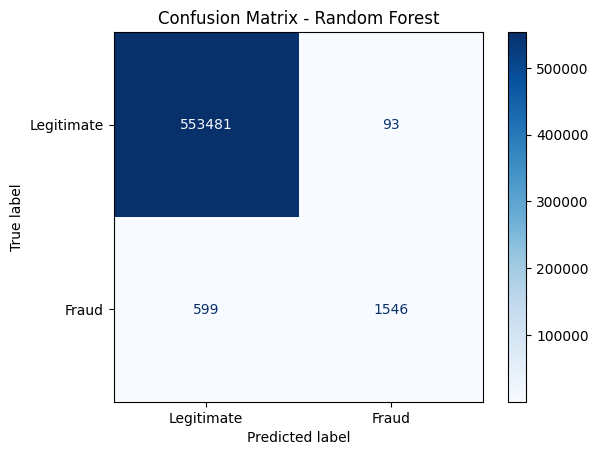

Random Forest confusion matrix values:
TN: 553481 FP: 93
FN: 599 TP: 1546
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/random_forest_confusion_matrix_normalized_true.png


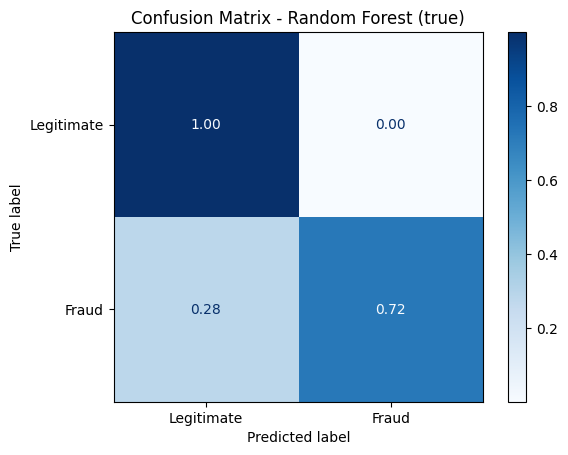

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/random_forest.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/predictions/random_forest_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports/random_forest_metrics.json
time: 14min 40s (started: 2026-06-10 20:13:01 +00:00)


In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

results["Random Forest"] = evaluate_sklearn_model(
    model_name="Random Forest",
    model=random_forest_model,
    X_train_data=X_train_model,
    y_train_data=y_train_model,
    X_test_data=X_test_model,
    y_test_data=y_test_model,
    threshold=0.5,
    save=True,
)

## Train and Save XGBoost

XGBoost is one of our high-recall models.
It is expected to catch many fraud cases, sometimes with more false alarms.

Training: XGBoost
Training time: 42.70 seconds
Inference time on test set: 3.63 seconds
XGBoost
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.31      0.94      0.47      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.96      0.73    555719
weighted avg       1.00      0.99      0.99    555719

{'Precision': 0.3122572627000155, 'Recall': 0.9370629370629371, 'F1': 0.46842227918900026, 'Balanced Accuracy': np.float64(0.964532906460273), 'ROC-AUC': np.float64(0.9970784675900884), 'PR-AUC': np.float64(0.8711830128472388), 'TP': 2010, 'FP': 4427, 'FN': 135, 'TN': 549147, 'False Alarm Rate': 0.007997124142391081}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/xgboost_confusion_matrix.png


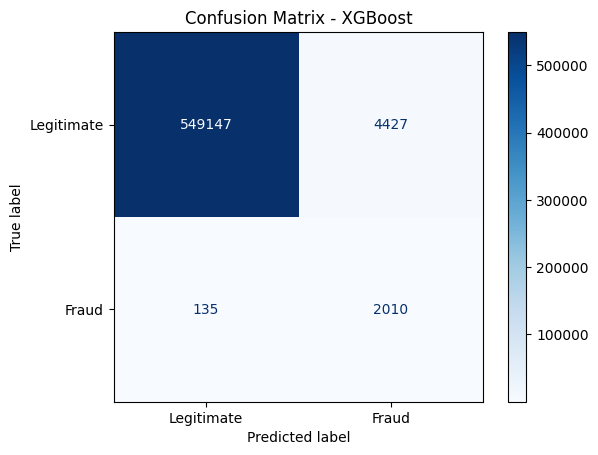

XGBoost confusion matrix values:
TN: 549147 FP: 4427
FN: 135 TP: 2010
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/xgboost_confusion_matrix_normalized_true.png


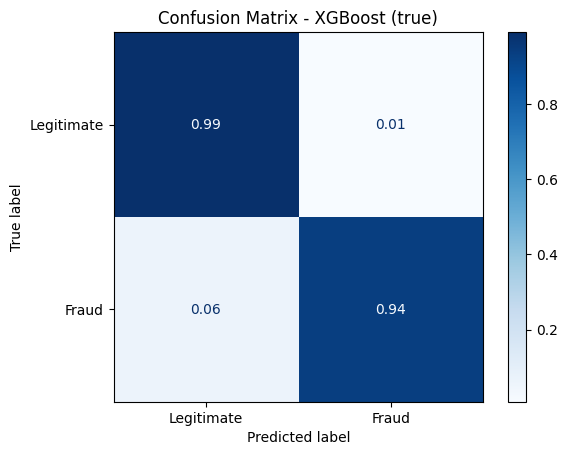

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/xgboost.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/predictions/xgboost_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports/xgboost_metrics.json
Saved native XGBoost model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/xgboost_model.json
time: 48.3 s (started: 2026-06-10 20:27:41 +00:00)


In [ ]:
xgboost_model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=pos_weight,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

results["XGBoost"] = evaluate_sklearn_model(
    model_name="XGBoost",
    model=xgboost_model,
    X_train_data=X_train_model,
    y_train_data=y_train_model,
    X_test_data=X_test_model,
    y_test_data=y_test_model,
    threshold=0.5,
    save=True,
)

xgboost_native_path = os.path.join(MODELS_DIR, "xgboost_model.json")
xgboost_model.save_model(xgboost_native_path)
print("Saved native XGBoost model:", xgboost_native_path)

##  Train and Save LightGBM

LightGBM is our balanced model.
In the previous notebook, it gave a strong balance between fraud recall and false alarms.

Training: LightGBM
Training time: 47.53 seconds
Inference time on test set: 10.25 seconds
LightGBM
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.46      0.90      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.95      0.80    555719
weighted avg       1.00      1.00      1.00    555719

{'Precision': 0.4564029460679496, 'Recall': 0.8955710955710956, 'F1': 0.6046584828454517, 'Balanced Accuracy': np.float64(0.9457189767399423), 'ROC-AUC': np.float64(0.9966552486822586), 'PR-AUC': np.float64(0.8713767052341349), 'TP': 1921, 'FP': 2288, 'FN': 224, 'TN': 551286, 'False Alarm Rate': 0.004133142091210931}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/lightgbm_confusion_matrix.png


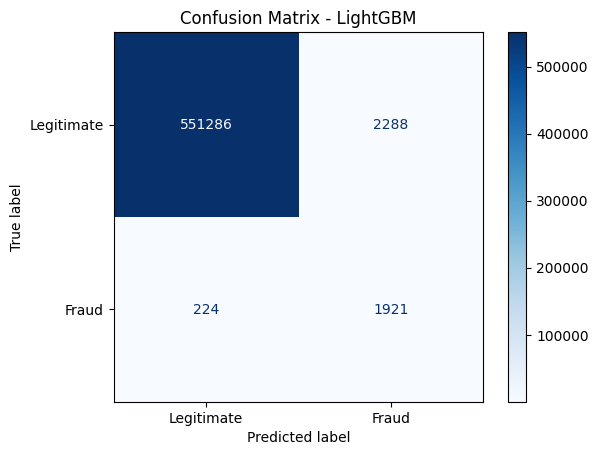

LightGBM confusion matrix values:
TN: 551286 FP: 2288
FN: 224 TP: 1921
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/lightgbm_confusion_matrix_normalized_true.png


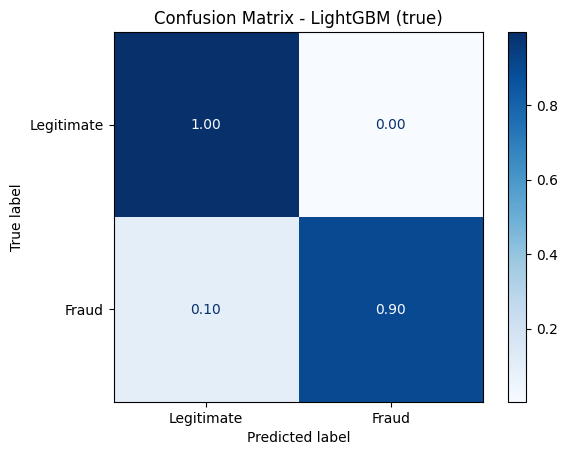

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/lightgbm.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/predictions/lightgbm_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports/lightgbm_metrics.json
time: 1min (started: 2026-06-10 20:28:29 +00:00)


In [ ]:
lightgbm_model = LGBMClassifier(
    n_estimators=350,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

results["LightGBM"] = evaluate_sklearn_model(
    model_name="LightGBM",
    model=lightgbm_model,
    X_train_data=X_train_model,
    y_train_data=y_train_model,
    X_test_data=X_test_model,
    y_test_data=y_test_model,
    threshold=0.5,
    save=True,
)

## Train and Save CatBoost

CatBoost is another high-recall model.
It is important because it may detect fraud cases that XGBoost or LightGBM miss.

Training: CatBoost
Training time: 184.13 seconds
Inference time on test set: 0.27 seconds
CatBoost
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.30      0.95      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.97      0.72    555719
weighted avg       1.00      0.99      0.99    555719

{'Precision': 0.29568251199302226, 'Recall': 0.9482517482517483, 'F1': 0.4507978723404255, 'Balanced Accuracy': np.float64(0.9697497654213468), 'ROC-AUC': np.float64(0.997062305607866), 'PR-AUC': np.float64(0.8693632076760471), 'TP': 2034, 'FP': 4845, 'FN': 111, 'TN': 548729, 'False Alarm Rate': 0.008752217409054616}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/catboost_confusion_matrix.png


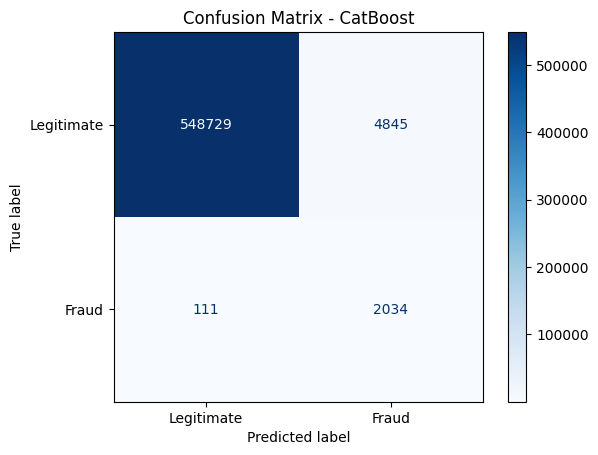

CatBoost confusion matrix values:
TN: 548729 FP: 4845
FN: 111 TP: 2034
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/catboost_confusion_matrix_normalized_true.png


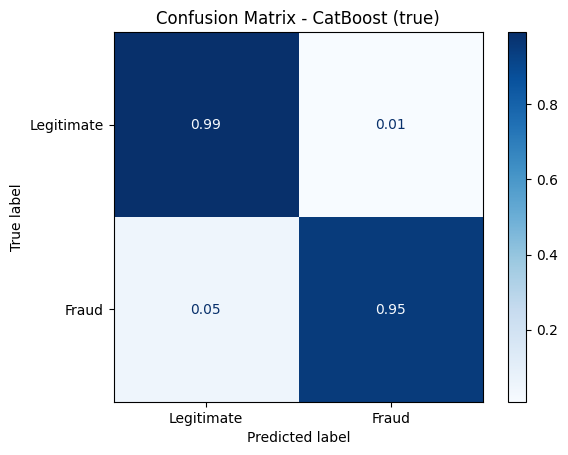

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/catboost.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/predictions/catboost_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports/catboost_metrics.json
Saved native CatBoost model: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/catboost_model.cbm
time: 3min 6s (started: 2026-06-10 20:29:29 +00:00)


In [ ]:
catboost_model = CatBoostClassifier(
    iterations=350,
    learning_rate=0.05,
    depth=8,
    auto_class_weights="Balanced",
    loss_function="Logloss",
    eval_metric="PRAUC",
    verbose=0,
    random_state=RANDOM_STATE,
)

results["CatBoost"] = evaluate_sklearn_model(
    model_name="CatBoost",
    model=catboost_model,
    X_train_data=X_train_model,
    y_train_data=y_train_model,
    X_test_data=X_test_model,
    y_test_data=y_test_model,
    threshold=0.5,
    save=True,
)

catboost_native_path = os.path.join(MODELS_DIR, "catboost_model.cbm")
catboost_model.save_model(catboost_native_path)
print("Saved native CatBoost model:", catboost_native_path)

## Train and Save Neural Network

Unlike the tree-based models, the Neural Network may learn different nonlinear patterns.

The goal is not necessarily to beat LightGBM alone, but to contribute unique information that can improve the final stacking ensemble.

### Scale Features

In [ ]:
nn_scaler = StandardScaler()

X_train_nn = nn_scaler.fit_transform(X_train_model)
X_test_nn = nn_scaler.transform(X_test_model)

print(X_train_nn.shape)
print(X_test_nn.shape)

(1296675, 16)
(555719, 16)
time: 472 ms (started: 2026-06-10 20:32:36 +00:00)


### Class Weight

In [ ]:
classes = np.unique(y_train_model)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_model
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 0.5029111776656126, 1: 86.37589928057554}
time: 339 ms (started: 2026-06-10 20:32:37 +00:00)


### Build NN Model

In [ ]:
def build_neural_network(input_dim):

    model = keras.Sequential([

        layers.Input(shape=(input_dim,)),

        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.30),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.30),

        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.20),

        layers.Dense(32),
        layers.Activation("relu"),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(
                name="roc_auc"
            ),
            keras.metrics.AUC(
                curve="PR",
                name="pr_auc"
            )
        ]
    )

    return model

time: 1.47 ms (started: 2026-06-10 20:35:48 +00:00)


### Callbacks

In [ ]:
best_nn_path = os.path.join(
    MODELS_DIR,
    "best_neural_network.keras"
)

training_log_path = os.path.join(
    REPORTS_DIR,
    "neural_network_training_log.csv"
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=best_nn_path,
    monitor="val_pr_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

csv_logger = keras.callbacks.CSVLogger(
    training_log_path
)

time: 1.53 ms (started: 2026-06-10 20:35:57 +00:00)


###Train

In [ ]:
nn_model = build_neural_network(
    input_dim=X_train_nn.shape[1]
)

time: 4.35 s (started: 2026-06-10 20:36:03 +00:00)


In [ ]:
nn_model = build_neural_network(
    input_dim=X_train_nn.shape[1]
)

start_time = time.time()

history = nn_model.fit(
    X_train_nn,
    y_train_model,
    validation_split=0.20,
    epochs=50,
    batch_size=4096,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint,
        csv_logger
    ],
    verbose=1
)

training_time = time.time() - start_time

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

Epoch 1/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4589 - pr_auc: 0.1679 - roc_auc: 0.8511
Epoch 1: val_pr_auc improved from None to 0.24004, saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/best_neural_network.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/best_neural_network.keras
254/254 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 0.4040 - pr_auc: 0.1946 - roc_auc: 0.8866 - val_loss: 0.4291 - val_pr_auc: 0.2400 - val_roc_auc: 0.9383 - learning_rate: 0.0010
Epoch 2/50
249/254 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3363 - pr_auc: 0.2298 - roc_auc: 0.9278
Epoch 2: val_pr_auc improved from 0.24004 to 0.25715, saving model to /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/models/best_neural_network.keras

Epoch 2: finished saving model t

### Load Best Model

In [ ]:
nn_model = keras.models.load_model(
    best_nn_path
)

print("Loaded best neural network model.")

Loaded best neural network model.
time: 285 ms (started: 2026-06-10 20:37:22 +00:00)


### Predict

In [ ]:
start_time = time.time()

nn_prob = (
    nn_model.predict(
        X_test_nn,
        batch_size=8192,
        verbose=0
    )
    .flatten()
)

inference_time = time.time() - start_time

nn_pred = (nn_prob >= 0.5).astype(int)

print(
    "Inference Time:",
    round(inference_time, 2),
    "seconds"
)

Inference Time: 1.26 seconds
time: 1.26 s (started: 2026-06-10 20:37:22 +00:00)


### Evaluate

Neural Network
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98    553574
       Fraud       0.08      0.94      0.14      2145

    accuracy                           0.96    555719
   macro avg       0.54      0.95      0.56    555719
weighted avg       1.00      0.96      0.97    555719

{'Precision': 0.07835011618900077, 'Recall': 0.9431235431235431, 'F1': 0.14468085106382977, 'Balanced Accuracy': np.float64(0.9500678068885752), 'ROC-AUC': np.float64(0.9894468589165233), 'PR-AUC': np.float64(0.7437475059838444), 'TP': 2023, 'FP': 23797, 'FN': 122, 'TN': 529777, 'False Alarm Rate': 0.042987929346392714}
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/neural_network_confusion_matrix.png


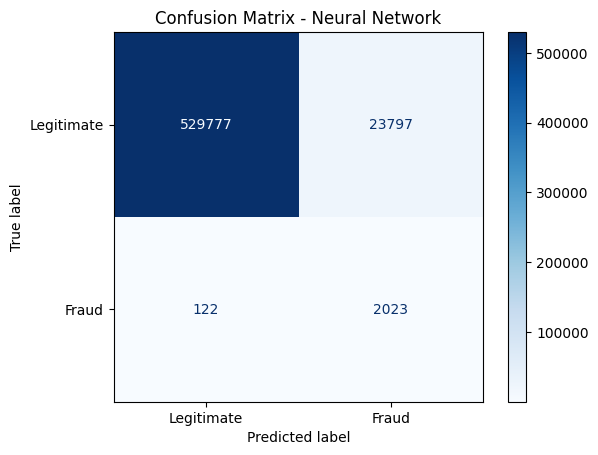

Neural Network confusion matrix values:
TN: 529777 FP: 23797
FN: 122 TP: 2023
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/neural_network_confusion_matrix_normalized_true.png


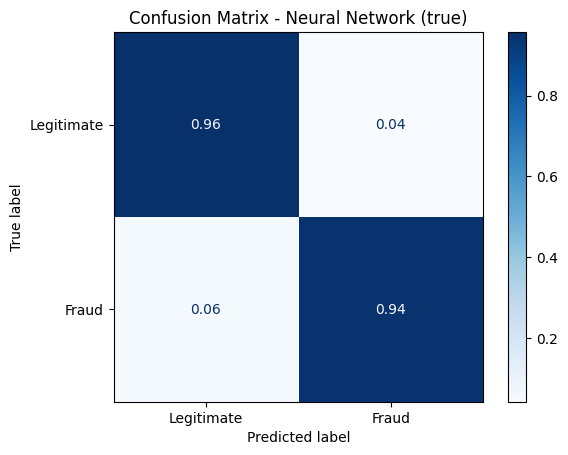

time: 978 ms (started: 2026-06-10 20:37:24 +00:00)


In [ ]:
nn_scores, nn_pred = evaluate_predictions(
    model_name="Neural Network",
    y_true=y_test_model,
    y_prob=nn_prob,
    threshold=0.5,
    save_prefix="neural_network",
)

### Save Scaler

In [ ]:
nn_scaler_path = os.path.join(
    PREPROCESSING_DIR,
    "neural_network_scaler.joblib"
)

joblib.dump(
    nn_scaler,
    nn_scaler_path
)

print("Saved scaler:", nn_scaler_path)

Saved scaler: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/preprocessing/neural_network_scaler.joblib
time: 11.8 ms (started: 2026-06-10 20:37:25 +00:00)


### Add to Results Dictionary

In [ ]:
results["Neural Network"] = {
    "model": nn_model,
    "y_pred": nn_pred,
    "y_prob": nn_prob,
    "scores": nn_scores,
    "threshold": 0.5,
    "training_time_seconds": training_time,
    "inference_time_seconds": inference_time,
}

time: 649 µs (started: 2026-06-10 20:37:25 +00:00)


# Model Comparison

All models were trained under identical conditions.

This section compares:

- Precision
- Recall
- F1
- Balanced Accuracy
- ROC-AUC
- PR-AUC
- Training Time
- Inference Time

The goal is to identify which models are strongest individually before building the stacking ensemble.

## Comparison Table

In [ ]:
comparison_df = pd.DataFrame({
    model_name: result["scores"]
    for model_name, result in results.items()
}).T

comparison_df["Training Time (sec)"] = [
    results[m]["training_time_seconds"]
    for m in comparison_df.index
]

comparison_df["Inference Time (sec)"] = [
    results[m]["inference_time_seconds"]
    for m in comparison_df.index
]

comparison_df["Threshold"] = [
    results[m]["threshold"]
    for m in comparison_df.index
]

comparison_df = comparison_df.sort_values(
    by="PR-AUC",
    ascending=False
)

comparison_df

,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TP,FP,FN,TN,False Alarm Rate,Training Time (sec),Inference Time (sec),Threshold
LightGBM,0.456403,0.895571,0.604658,0.945719,0.996655,0.871377,1921.0,2288.0,224.0,551286.0,0.004133,47.530251,10.254772,0.5
XGBoost,0.312257,0.937063,0.468422,0.964533,0.997078,0.871183,2010.0,4427.0,135.0,549147.0,0.007997,42.701363,3.626968,0.5
CatBoost,0.295683,0.948252,0.450798,0.969750,0.997062,0.869363,2034.0,4845.0,111.0,548729.0,0.008752,184.132653,0.268313,0.5
Random Forest,0.943258,0.720746,0.817125,0.860289,0.986724,0.867069,1546.0,93.0,599.0,553481.0,0.000168,867.993784,8.818805,0.5
Neural Network,0.078350,0.943124,0.144681,0.950068,0.989447,0.743748,2023.0,23797.0,122.0,529777.0,0.042988,74.006645,1.258636,0.5


time: 37.2 ms (started: 2026-06-10 20:37:25 +00:00)


## Save Comparison

In [ ]:
comparison_path = os.path.join(
    REPORTS_DIR,
    "model_comparison_metrics.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=True
)

print("Saved:", comparison_path)

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports/model_comparison_metrics.csv
time: 9.64 ms (started: 2026-06-10 20:37:25 +00:00)


## Visual Comparison

In [ ]:
metrics_to_plot = [
    "PR-AUC",
    "ROC-AUC",
    "Recall",
    "Precision",
    "F1",
    "Balanced Accuracy",
]

time: 350 µs (started: 2026-06-10 20:37:25 +00:00)


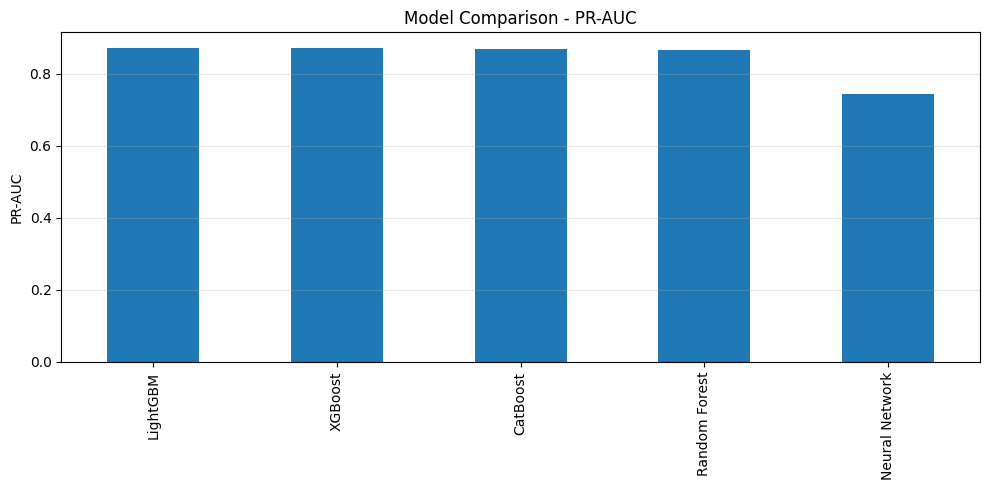

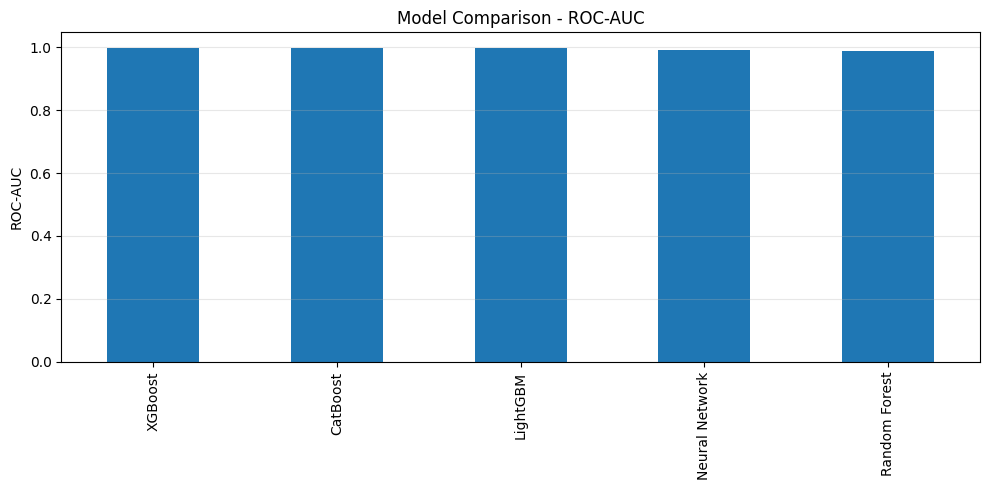

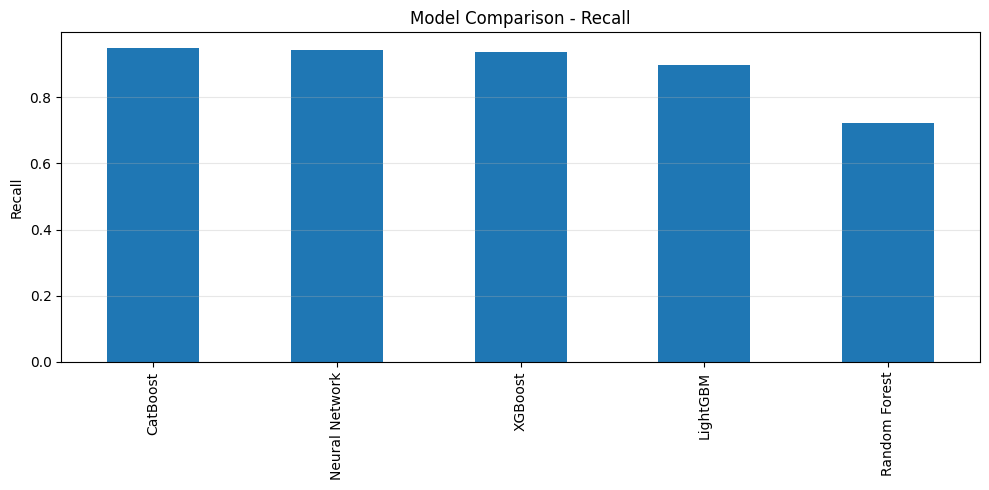

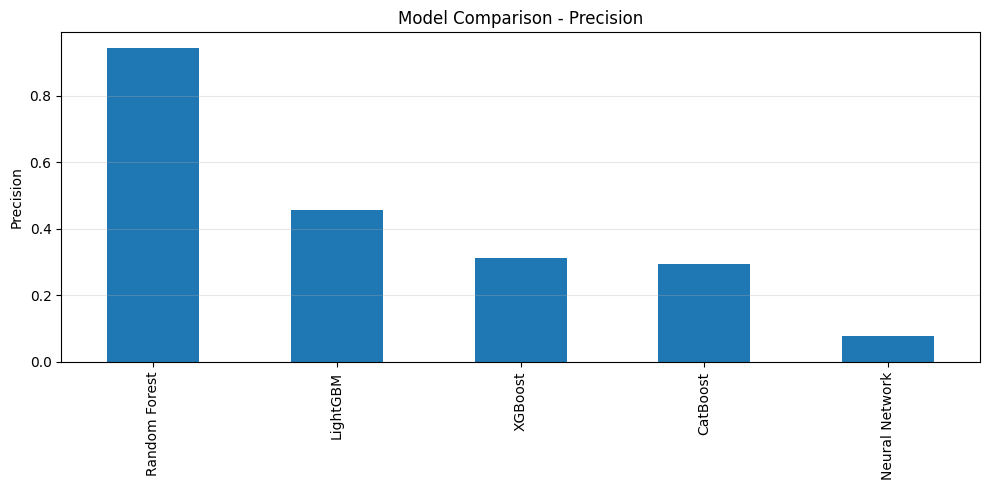

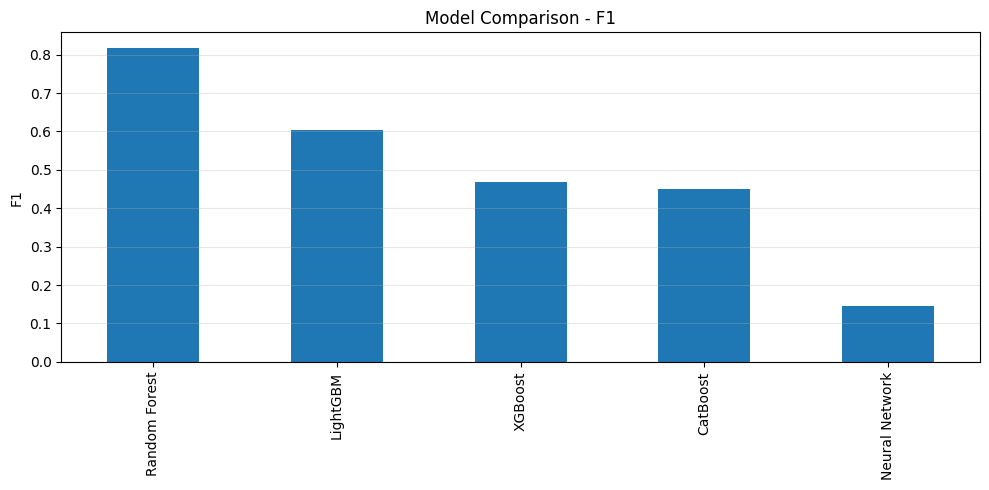

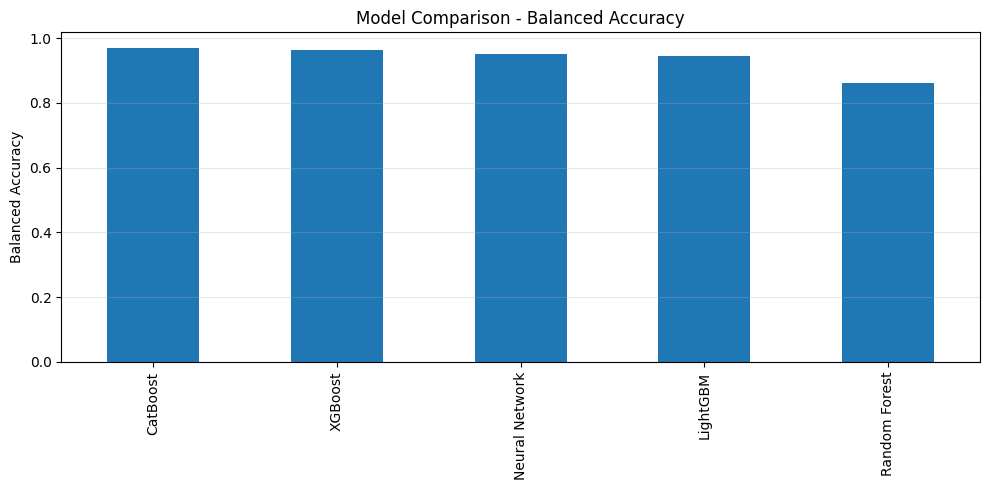

time: 927 ms (started: 2026-06-10 20:37:25 +00:00)


In [ ]:
for metric in metrics_to_plot:

    plt.figure(figsize=(10,5))

    comparison_df[metric]\
        .sort_values(ascending=False)\
        .plot(kind="bar")

    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
for model_name in results:
  print(model_name)
  print(results[model_name]["scores"])

Random Forest
{'Precision': 0.9432580841976815, 'Recall': 0.7207459207459207, 'F1': 0.8171247357293869, 'Balanced Accuracy': np.float64(0.8602889607631521), 'ROC-AUC': np.float64(0.9867241615856976), 'PR-AUC': np.float64(0.8670685043348978), 'TP': 1546, 'FP': 93, 'FN': 599, 'TN': 553481, 'False Alarm Rate': 0.00016799921961652823}
XGBoost
{'Precision': 0.3122572627000155, 'Recall': 0.9370629370629371, 'F1': 0.46842227918900026, 'Balanced Accuracy': np.float64(0.964532906460273), 'ROC-AUC': np.float64(0.9970784675900884), 'PR-AUC': np.float64(0.8711830128472388), 'TP': 2010, 'FP': 4427, 'FN': 135, 'TN': 549147, 'False Alarm Rate': 0.007997124142391081}
LightGBM
{'Precision': 0.4564029460679496, 'Recall': 0.8955710955710956, 'F1': 0.6046584828454517, 'Balanced Accuracy': np.float64(0.9457189767399423), 'ROC-AUC': np.float64(0.9966552486822586), 'PR-AUC': np.float64(0.8713767052341349), 'TP': 1921, 'FP': 2288, 'FN': 224, 'TN': 551286, 'False Alarm Rate': 0.004133142091210931}
CatBoost
{'P

## Build Prediction Table

In [ ]:
prediction_analysis_df = pd.DataFrame({
    "y_true": y_test_model.values if hasattr(y_test_model, "values") else y_test_model
})

for model_name, result in results.items():
    safe_name = clean_model_name(model_name)
    prediction_analysis_df[f"{safe_name}_prob"] = result["y_prob"]
    prediction_analysis_df[f"{safe_name}_pred"] = result["y_pred"]

prediction_analysis_df.head()

,y_true,random_forest_prob,random_forest_pred,xgboost_prob,xgboost_pred,lightgbm_prob,lightgbm_pred,catboost_prob,catboost_pred,neural_network_prob,neural_network_pred
0,0,0.0,0,0.000304,0,0.000360,0,0.000317,0,0.018135,0
1,0,0.0,0,0.007654,0,0.001150,0,0.001293,0,0.025462,0
2,0,0.0,0,0.000497,0,0.000143,0,0.000918,0,0.004016,0
3,0,0.0,0,0.000329,0,0.000085,0,0.000151,0,0.000225,0
4,0,0.0,0,0.001084,0,0.000460,0,0.001691,0,0.025730,0


time: 31.6 ms (started: 2026-06-10 21:11:32 +00:00)


## Agreement Matrix

In [ ]:
model_names = list(results.keys())
pred_cols = [f"{clean_model_name(m)}_pred" for m in model_names]

agreement_matrix = pd.DataFrame(
    index=model_names,
    columns=model_names,
    dtype=float
)

for m1 in model_names:
    for m2 in model_names:
        col1 = f"{clean_model_name(m1)}_pred"
        col2 = f"{clean_model_name(m2)}_pred"

        agreement = (
            prediction_analysis_df[col1] == prediction_analysis_df[col2]
        ).mean()

        agreement_matrix.loc[m1, m2] = agreement

agreement_matrix

,Random Forest,XGBoost,LightGBM,CatBoost,Neural Network
Random Forest,1.000000,0.991363,0.995332,0.990571,0.956487
XGBoost,0.991363,1.000000,0.995296,0.995904,0.961220
LightGBM,0.995332,0.995296,1.000000,0.994378,0.959283
CatBoost,0.990571,0.995904,0.994378,1.000000,0.961122
Neural Network,0.956487,0.961220,0.959283,0.961122,1.000000


time: 51.5 ms (started: 2026-06-10 21:11:32 +00:00)


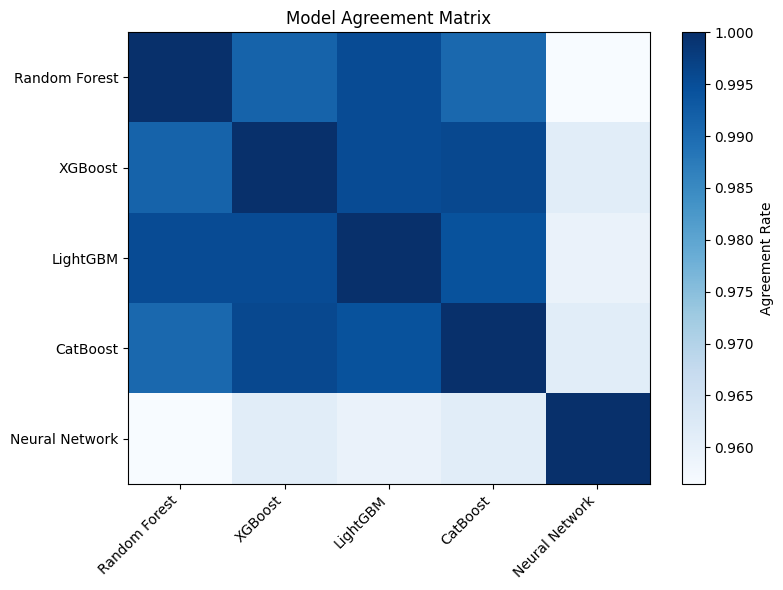

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/model_agreement_matrix.png
time: 2.23 s (started: 2026-06-10 21:16:05 +00:00)


In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(agreement_matrix.astype(float), aspect="auto", cmap="Blues")
plt.colorbar(label="Agreement Rate")

plt.xticks(range(len(model_names)), model_names, rotation=45, ha="right")
plt.yticks(range(len(model_names)), model_names)

plt.title("Model Agreement Matrix")
plt.tight_layout()

agreement_fig_path = os.path.join(FIGURES_DIR, "model_agreement_matrix.png")
plt.savefig(agreement_fig_path, bbox_inches="tight", dpi=150)
plt.show()

print("Saved:", agreement_fig_path)

## Fraud Detection Overlap

In [ ]:
fraud_cases_df = prediction_analysis_df[
    prediction_analysis_df["y_true"] == 1
].copy()

fraud_cases_df["models_detecting_fraud"] = fraud_cases_df[pred_cols].sum(axis=1)

fraud_overlap_summary = fraud_cases_df["models_detecting_fraud"].value_counts().sort_index()

fraud_overlap_summary

,count
models_detecting_fraud,
0,72
1,39
2,42
3,102
4,345
5,1545


time: 15.2 ms (started: 2026-06-10 21:11:33 +00:00)


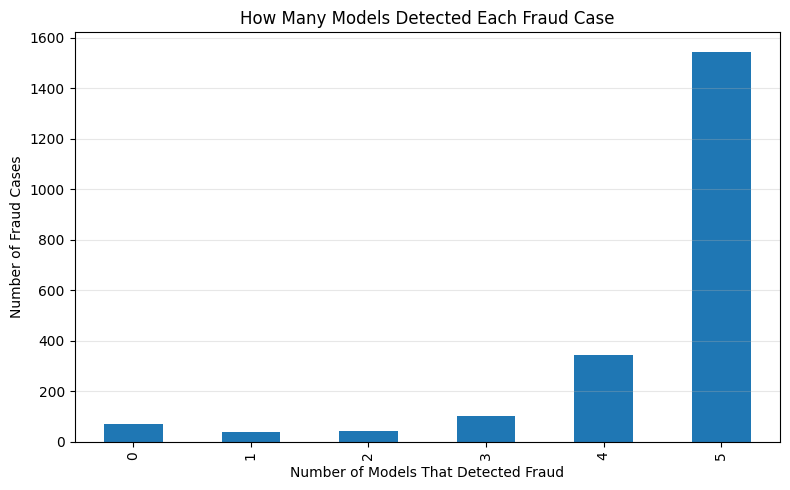

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/fraud_detection_overlap.png
time: 340 ms (started: 2026-06-10 21:11:33 +00:00)


In [ ]:
plt.figure(figsize=(8, 5))

fraud_overlap_summary.plot(kind="bar")

plt.title("How Many Models Detected Each Fraud Case")
plt.xlabel("Number of Models That Detected Fraud")
plt.ylabel("Number of Fraud Cases")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

fraud_overlap_path = os.path.join(FIGURES_DIR, "fraud_detection_overlap.png")
plt.savefig(fraud_overlap_path, bbox_inches="tight", dpi=150)
plt.show()

print("Saved:", fraud_overlap_path)

## Unique Fraud Detection

In [ ]:
unique_fraud_rows = []

for model_name in model_names:
    model_col = f"{clean_model_name(model_name)}_pred"

    other_cols = [
        f"{clean_model_name(other)}_pred"
        for other in model_names
        if other != model_name
    ]

    unique_detected = fraud_cases_df[
        (fraud_cases_df[model_col] == 1) &
        (fraud_cases_df[other_cols].sum(axis=1) == 0)
    ]

    total_detected = fraud_cases_df[fraud_cases_df[model_col] == 1]

    unique_fraud_rows.append({
        "Model": model_name,
        "Detected Frauds": len(total_detected),
        "Unique Frauds Detected": len(unique_detected),
        "Unique Detection Rate": len(unique_detected) / max(len(total_detected), 1)
    })

unique_fraud_df = pd.DataFrame(unique_fraud_rows)
unique_fraud_df = unique_fraud_df.sort_values("Unique Frauds Detected", ascending=False)

unique_fraud_df

,Model,Detected Frauds,Unique Frauds Detected,Unique Detection Rate
4,Neural Network,2023,27,0.013347
3,CatBoost,2034,7,0.003441
2,LightGBM,1921,3,0.001562
1,XGBoost,2010,2,0.000995
0,Random Forest,1546,0,0.000000


time: 28.5 ms (started: 2026-06-10 21:11:33 +00:00)


## Missed Fraud Analysis

In [ ]:
frauds_missed_by_all = fraud_cases_df[
    fraud_cases_df[pred_cols].sum(axis=1) == 0
]

print("Frauds missed by all models:", len(frauds_missed_by_all))
print("Total frauds:", len(fraud_cases_df))
print("Missed by all rate:", len(frauds_missed_by_all) / len(fraud_cases_df))

frauds_missed_by_all.head()

Frauds missed by all models: 72
Total frauds: 2145
Missed by all rate: 0.033566433566433566


,y_true,random_forest_prob,random_forest_pred,xgboost_prob,xgboost_pred,lightgbm_prob,lightgbm_pred,catboost_prob,catboost_pred,neural_network_prob,neural_network_pred,models_detecting_fraud
1685,1,0.000000,0,0.049516,0,0.014059,0,0.237663,0,0.294969,0,0
15411,1,0.000000,0,0.006827,0,0.003455,0,0.040838,0,0.077241,0,0
26780,1,0.003977,0,0.209447,0,0.039145,0,0.490121,0,0.346572,0,0
28628,1,0.008000,0,0.143031,0,0.042397,0,0.184869,0,0.075340,0,0
31084,1,0.007932,0,0.085409,0,0.060396,0,0.112689,0,0.001584,0,0


time: 30.9 ms (started: 2026-06-10 21:11:33 +00:00)


## False Positive Overlap

In [ ]:
legitimate_cases_df = prediction_analysis_df[
    prediction_analysis_df["y_true"] == 0
].copy()

legitimate_cases_df["models_false_alarm"] = legitimate_cases_df[pred_cols].sum(axis=1)

false_positive_overlap_summary = legitimate_cases_df[
    legitimate_cases_df["models_false_alarm"] > 0
]["models_false_alarm"].value_counts().sort_index()

false_positive_overlap_summary

,count
models_false_alarm,
1,20372
2,1790
3,1632
4,1548
5,82


time: 148 ms (started: 2026-06-10 21:11:33 +00:00)


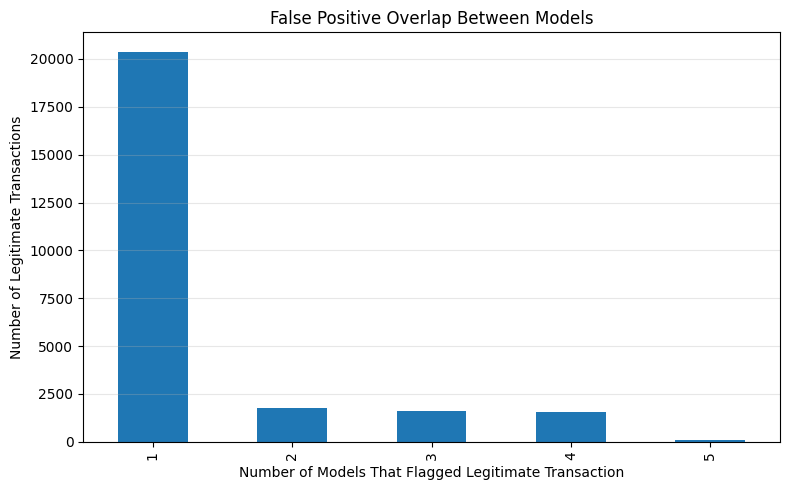

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/false_positive_overlap.png
time: 323 ms (started: 2026-06-10 21:11:33 +00:00)


In [ ]:
plt.figure(figsize=(8, 5))

false_positive_overlap_summary.plot(kind="bar")

plt.title("False Positive Overlap Between Models")
plt.xlabel("Number of Models That Flagged Legitimate Transaction")
plt.ylabel("Number of Legitimate Transactions")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

fp_overlap_path = os.path.join(FIGURES_DIR, "false_positive_overlap.png")
plt.savefig(fp_overlap_path, bbox_inches="tight", dpi=150)
plt.show()

print("Saved:", fp_overlap_path)

### Save Analysis Tables

In [ ]:
agreement_matrix_path = os.path.join(REPORTS_DIR, "model_agreement_matrix.csv")
unique_fraud_path = os.path.join(REPORTS_DIR, "unique_fraud_detection.csv")
prediction_analysis_path = os.path.join(PREDICTIONS_DIR, "model_overlap_predictions.csv")

agreement_matrix.to_csv(agreement_matrix_path)
unique_fraud_df.to_csv(unique_fraud_path, index=False)
prediction_analysis_df.to_csv(prediction_analysis_path, index=False)

print("Saved agreement matrix:", agreement_matrix_path)
print("Saved unique fraud analysis:", unique_fraud_path)
print("Saved prediction analysis:", prediction_analysis_path)

Saved agreement matrix: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports/model_agreement_matrix.csv
Saved unique fraud analysis: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/reports/unique_fraud_detection.csv
Saved prediction analysis: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/predictions/model_overlap_predictions.csv
time: 4.42 s (started: 2026-06-10 21:11:34 +00:00)


### Automatic Conclusion

In [ ]:
print("=" * 80)
print("MODEL DIVERSITY ANALYSIS SUMMARY")
print("=" * 80)

print("\nFraud overlap:")
print(fraud_overlap_summary)

print("\nUnique fraud detection:")
display(unique_fraud_df)

print("\nFrauds missed by all models:", len(frauds_missed_by_all))

print("\nInterpretation:")
print("""
If a model detects many unique fraud cases, it may be useful for stacking even if its standalone metrics are weaker.

If two models detect almost exactly the same frauds and create similar false positives,
they may be partially redundant.

If the Neural Network detects frauds that the tree models miss,
it may still be useful as a diversity model in the final stacking ensemble.
""")

MODEL DIVERSITY ANALYSIS SUMMARY

Fraud overlap:
models_detecting_fraud
0      72
1      39
2      42
3     102
4     345
5    1545
Name: count, dtype: int64

Unique fraud detection:


,Model,Detected Frauds,Unique Frauds Detected,Unique Detection Rate
4,Neural Network,2023,27,0.013347
3,CatBoost,2034,7,0.003441
2,LightGBM,1921,3,0.001562
1,XGBoost,2010,2,0.000995
0,Random Forest,1546,0,0.000000



Frauds missed by all models: 72

Interpretation:

If a model detects many unique fraud cases, it may be useful for stacking even if its standalone metrics are weaker.

If two models detect almost exactly the same frauds and create similar false positives,
they may be partially redundant.

If the Neural Network detects frauds that the tree models miss,
it may still be useful as a diversity model in the final stacking ensemble.

time: 16.4 ms (started: 2026-06-10 21:11:38 +00:00)


## Create Probability DataFrame

In [60]:
probability_df = pd.DataFrame()

for model_name, result in results.items():

    probability_df[model_name] = result["y_prob"]

probability_df.head()

,Random Forest,XGBoost,LightGBM,CatBoost,Neural Network
0,0.0,0.000304,0.000360,0.000317,0.018135
1,0.0,0.007654,0.001150,0.001293,0.025462
2,0.0,0.000497,0.000143,0.000918,0.004016
3,0.0,0.000329,0.000085,0.000151,0.000225
4,0.0,0.001084,0.000460,0.001691,0.025730


time: 60.9 ms (started: 2026-06-10 21:23:03 +00:00)


## Correlation Matrix

In [61]:
correlation_matrix = probability_df.corr()

correlation_matrix

,Random Forest,XGBoost,LightGBM,CatBoost,Neural Network
Random Forest,1.000000,0.682692,0.790471,0.667075,0.395235
XGBoost,0.682692,1.000000,0.908369,0.937511,0.560165
LightGBM,0.790471,0.908369,1.000000,0.872004,0.484168
CatBoost,0.667075,0.937511,0.872004,1.000000,0.578100
Neural Network,0.395235,0.560165,0.484168,0.578100,1.000000


time: 300 ms (started: 2026-06-10 21:23:06 +00:00)


## Heatmap

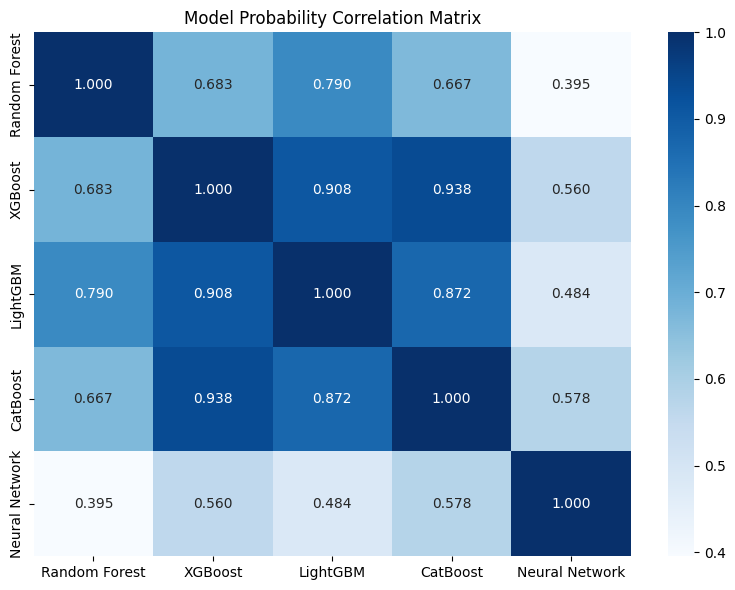

Saved: /content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/model_selection_before_stacking/figures/probability_correlation_matrix.png
time: 1.64 s (started: 2026-06-10 21:23:09 +00:00)


In [62]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title("Model Probability Correlation Matrix")

plt.tight_layout()

correlation_path = os.path.join(
    FIGURES_DIR,
    "probability_correlation_matrix.png"
)

plt.savefig(
    correlation_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", correlation_path)

## Diversity Score

In [63]:
rows = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        model_1 = correlation_matrix.columns[i]
        model_2 = correlation_matrix.columns[j]

        corr = correlation_matrix.iloc[i, j]

        rows.append({
            "Model A": model_1,
            "Model B": model_2,
            "Correlation": corr,
            "Diversity Score": 1 - corr
        })

diversity_df = pd.DataFrame(rows)

diversity_df = diversity_df.sort_values(
    "Correlation",
    ascending=False
)

diversity_df

,Model A,Model B,Correlation,Diversity Score
5,XGBoost,CatBoost,0.937511,0.062489
4,XGBoost,LightGBM,0.908369,0.091631
7,LightGBM,CatBoost,0.872004,0.127996
1,Random Forest,LightGBM,0.790471,0.209529
0,Random Forest,XGBoost,0.682692,0.317308
2,Random Forest,CatBoost,0.667075,0.332925
9,CatBoost,Neural Network,0.578100,0.421900
6,XGBoost,Neural Network,0.560165,0.439835
8,LightGBM,Neural Network,0.484168,0.515832
3,Random Forest,Neural Network,0.395235,0.604765


time: 31.1 ms (started: 2026-06-10 21:23:14 +00:00)
